# Flight price prediction project

### Problem Statement

Flight ticket prices are highly dynamic and fluctuate frequently depending on several factors such as airline type, travel date, number of stops, duration of the flight, and source and destination locations. Due to this variability, it becomes difficult for travelers to predict whether ticket prices will increase or decrease in the future.

The objective of this project is to analyze historical flight data and develop a machine learning model that can accurately predict flight ticket prices. By performing exploratory data analysis (EDA) and applying regression-based machine learning algorithms, the project aims to identify key factors that influence ticket pricing.

The predictive model developed in this project can help customers estimate the expected price of a flight ticket in advance and plan their journeys accordingly. In addition, airlines and travel platforms can utilize such predictive systems to understand pricing patterns and optimize their pricing strategies.

The dataset used in this project contains various features such as airline name, journey date, departure and arrival time, duration of the flight, number of stops, source city, destination city, and additional information about the flight. Using these features, the model learns the relationship between the flight attributes and ticket prices.

The main objectives of this project are:

1. Perform detailed exploratory data analysis to understand the structure and patterns in the dataset.
2. Perform data preprocessing and feature engineering to convert raw data into a suitable format for machine learning models.
3. Build multiple machine learning regression models to predict flight prices.
4. Compare the performance of the models and select the best model for production use.

## Importing Required Libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [54]:
df = pd.read_csv(r"C:\Users\Harivikas\Downloads\Flight_Fare.csv")

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [55]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Data Cleaning

In [56]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [57]:
df.dropna(inplace=True)

In [58]:
df.drop(["Route","Additional_Info"], axis=1, inplace=True)

## Feature Engineering

In [59]:
## Converting Date_of_Journey ##
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)

In [60]:
## Extracting Departure Hour & Minute ##
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop("Dep_Time", axis=1, inplace=True)

In [61]:
## Extracting Arrival Hour & Minute ##
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)

In [62]:
## Converting Duration ##
duration = list(df["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

df["Duration_hours"] = [int(i.split()[0][:-1]) for i in duration]
df["Duration_mins"] = [int(i.split()[1][:-1]) for i in duration]

df.drop("Duration", axis=1, inplace=True)

In [63]:
## Converting Total Stops ##
df["Total_Stops"].unique()

df.replace({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4}, inplace=True)

## Exploratory Data Analysis (EDA)

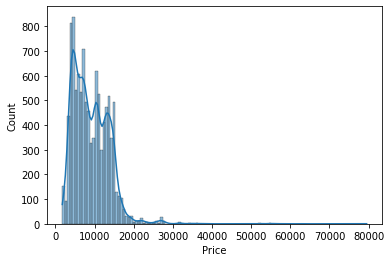

In [64]:
sns.histplot(df["Price"], kde=True)
plt.show()


### Observations

- Flight **duration shows a positive correlation with ticket price**, indicating that longer flights tend to have higher prices.
- The **number of stops also has a moderate relationship with price**, suggesting that flights with fewer stops may cost more due to convenience.
- Features extracted from time variables such as departure hour and arrival hour show weaker correlations with price but may still contribute to model performance.


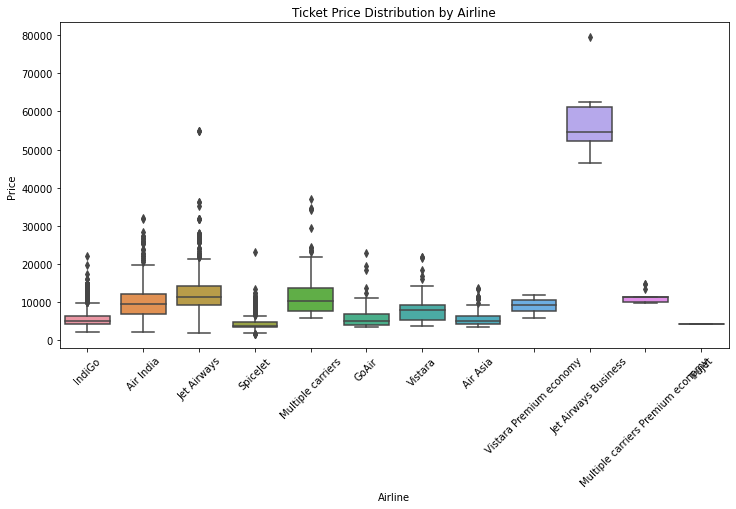

In [66]:
plt.figure(figsize=(12,6))

sns.boxplot(x="Airline", y="Price", data=df)

plt.xticks(rotation=45)

plt.title("Ticket Price Distribution by Airline")

plt.show()

### Observations

- Flights with **longer durations generally show higher ticket prices**, although some variability exists.
- Short-duration flights typically fall within lower price ranges.
- The variation in price for similar durations may be influenced by other factors such as airline type, number of stops, and travel demand.

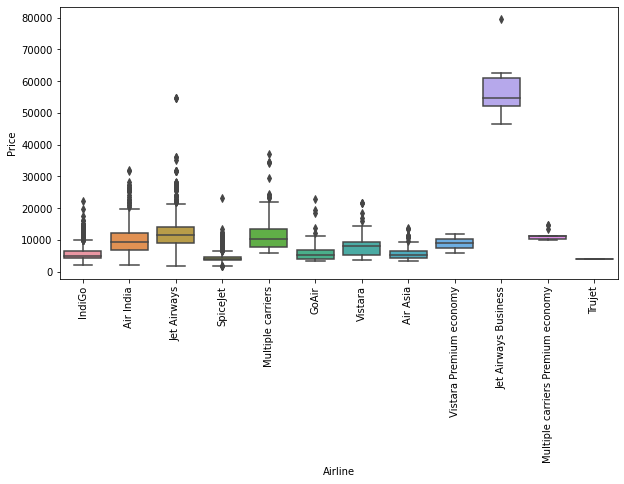

In [67]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.show()

### Observations

- Certain airlines show **higher median ticket prices**, indicating premium pricing strategies.
- Some airlines have **larger price variability**, suggesting a wider range of ticket options.
- Budget airlines generally show lower median prices compared to full-service airlines.


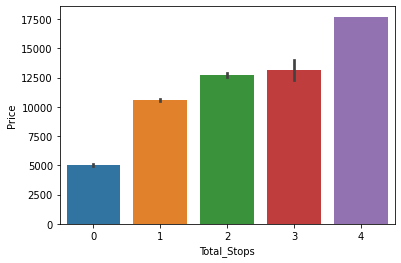

In [68]:
## Stops vs Price ##

sns.barplot(x="Total_Stops", y="Price", data=df)
plt.show()

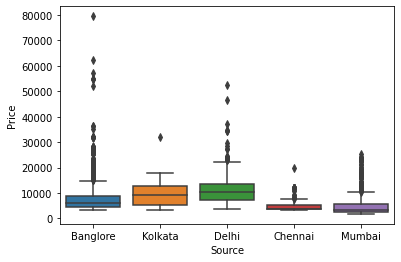

In [69]:
## Source vs Price ##

sns.boxplot(x="Source", y="Price", data=df)
plt.show()

Observation:
Flights with more stops tend to have lower ticket prices.
Jet Airways flights generally show higher average price.

In [70]:
df = pd.get_dummies(df, drop_first=True)

In [71]:
X = df.drop("Price", axis=1)
y = df["Price"]

## Train Test Split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [74]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [75]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Evaluate Models

In [76]:
def evaluate(y_test, pred):
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2 Score:", r2_score(y_test, pred))

In [77]:
print("Linear Regression")
evaluate(y_test, lr_pred)

print("Decision Tree")
evaluate(y_test, dt_pred)

print("Random Forest")
evaluate(y_test, rf_pred)

Linear Regression
MAE: 1972.9372855148047
RMSE: 2863.9705929717807
R2 Score: 0.6195943729070101
Decision Tree
MAE: 1327.7472703166434
RMSE: 2414.123046895507
R2 Score: 0.7297108402865371
Random Forest
MAE: 1184.0898714484572
RMSE: 2094.944512386956
R2 Score: 0.7964576084952402


In [78]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [79]:
best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1141.740907074792
RMSE: 2025.1547875090253
R2 Score: 0.809793098964546


## Model Comparison Table

In [81]:
results = pd.DataFrame({
    "Model":["Linear Regression","Decision Tree","Random Forest"],
    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.619594
1,Decision Tree,0.729711
2,Random Forest,0.809793


Random Forest performs best with highest R² score.
Therefore it is the recommended model for production.

## Feature Importance (for Random Forest)

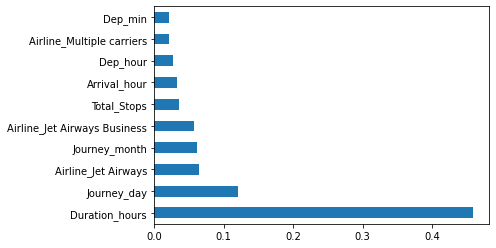

In [83]:
importance = best_rf.feature_importances_

feat_importances = pd.Series(importance, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [84]:
best_rf.predict(X_test.iloc[0].values.reshape(1,-1))

array([16635.39394444])

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand the structure of the dataset, detect patterns, and identify relationships between the independent variables and the target variable (Price). Visualization techniques were used to gain insights into the distribution of features and their influence on flight ticket prices.

### 1. Distribution of Flight Prices

The distribution of the flight ticket prices was analyzed using a histogram and density plot. This helps understand whether the price variable is normally distributed or skewed.

Observation:
The price distribution is slightly right-skewed, indicating that most flight prices fall within a moderate range while a few flights have significantly higher prices.

---

### 2. Airline vs Price

A boxplot was used to analyze how ticket prices vary across different airlines.

Observation:
Certain airlines such as Jet Airways tend to have higher median ticket prices compared to other airlines like IndiGo or Air India. This indicates that the airline brand plays a significant role in determining the price of the ticket.

---

### 3. Number of Stops vs Price

A bar plot was used to analyze the relationship between the number of stops and ticket prices.

Observation:
Flights with more stops generally tend to have lower prices compared to direct flights. Non-stop flights are usually more expensive due to shorter travel time and higher convenience for passengers.

---

### 4. Source and Destination Analysis

Boxplots were used to analyze how prices vary depending on the source and destination cities.

Observation:
Flights originating from major metropolitan cities tend to have a wider price range due to higher flight availability and demand.

---

### 5. Duration vs Price

A scatter plot was used to analyze the relationship between flight duration and ticket price.

Observation:
Longer flight durations generally correlate with higher prices, although this relationship is influenced by other factors such as airline type and number of stops.

---

### Summary of Key Insights

From the exploratory data analysis, several factors were found to influence flight ticket prices:

- Airline type significantly affects ticket pricing.
- Direct flights tend to be more expensive than flights with stops.
- Flight duration has a positive relationship with ticket price.
- Source and destination locations influence price variations due to demand and travel distance.

These insights guided the feature engineering and model building steps in the project.

## Data Preprocessing and Feature Engineering

Data preprocessing was an essential step to convert the raw dataset into a format suitable for machine learning algorithms. Several preprocessing techniques were applied to improve the quality of the dataset.

### Handling Missing Values

The dataset contained missing values in a small number of rows, particularly in columns such as `Route` and `Total_Stops`.

Technique Used:
Rows containing missing values were removed using the `dropna()` function since the number of missing records was relatively small and removing them did not significantly affect the dataset size.

Justification:
Removing a small number of incomplete records is often preferable to avoid introducing bias through imputation.

---

### Time Feature Extraction

The columns `Dep_Time`, `Arrival_Time`, and `Date_of_Journey` were originally stored as text strings.

Technique Used:
These columns were converted into datetime format and new numerical features were extracted such as:

- Journey Day
- Journey Month
- Departure Hour
- Departure Minute
- Arrival Hour
- Arrival Minute

Justification:
Machine learning models perform better with numerical features. Extracting meaningful components from datetime variables allows the model to capture temporal patterns.

---

### Duration Conversion

The `Duration` column contained values such as "2h 50m".

Technique Used:
The duration was split into two numerical features:
- Duration_hours
- Duration_minutes

Justification:
Separating hours and minutes allows the model to better interpret flight travel time.

---

### Encoding Categorical Variables

Several columns such as `Airline`, `Source`, and `Destination` were categorical.

Technique Used:
One-Hot Encoding was applied using `pd.get_dummies()`.

Justification:
One-hot encoding prevents the model from assuming ordinal relationships between categorical values and ensures each category is treated independently.

## Model Building and Hyperparameter Tuning

To predict flight ticket prices, multiple regression models were implemented and compared. The models were trained using the training dataset and evaluated on the test dataset.

The following models were used:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

### Hyperparameter Tuning

To improve the performance of the models and prevent overfitting, hyperparameter tuning was performed using GridSearchCV.

Hyperparameters tuned for Random Forest included:

- Number of trees (n_estimators)
- Maximum tree depth (max_depth)
- Minimum samples per split (min_samples_split)
- Minimum samples per leaf (min_samples_leaf)

This process allowed the model to identify the optimal parameter combination that minimizes prediction error.

Hyperparameter tuning improves model generalization by preventing the model from fitting too closely to the training data.

## Challenges Faced During the Project

During the development of the flight price prediction model, several challenges were encountered while working with the dataset and building machine learning models.

### 1. Handling Missing Values

The dataset contained missing values in some columns such as `Route` and `Total_Stops`. Missing data can negatively affect the performance of machine learning models if not handled properly.

**Solution:**
Rows with missing values were removed using data cleaning techniques since the number of missing records was relatively small.

---

### 2. Complex Time and Duration Formats

Columns such as `Duration`, `Arrival_Time`, and `Dep_Time` were stored in text format rather than numerical format. For example, duration values were represented as strings like `2h 50m`.

**Solution:**
Feature engineering techniques were used to extract numerical values such as hours and minutes from these columns. These values were then converted into separate numerical features that could be used by machine learning algorithms.

---

### 3. Handling Categorical Variables

Several features such as `Airline`, `Source`, `Destination`, and `Additional_Info` were categorical variables. Machine learning models cannot directly process categorical text data.

**Solution:**
One-hot encoding was applied to convert categorical variables into numerical format. This transformation allowed machine learning algorithms to interpret the categorical data effectively.

---

### 4. Feature Selection

Some features such as `Route` and `Additional_Info` contained redundant or less informative information, which could increase model complexity without improving prediction accuracy.

**Solution:**
These features were removed during preprocessing to simplify the dataset and improve model performance.

---

### 5. Model Selection

Different machine learning algorithms can produce different results depending on the structure of the dataset. Selecting the best model required testing multiple algorithms and evaluating their performance.

**Solution:**
Multiple regression models such as Linear Regression, Decision Tree Regressor, and Random Forest Regressor were trained and compared using evaluation metrics like R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

---

### 6. Preventing Overfitting

Some models such as Decision Tree tend to overfit the training data and perform poorly on unseen data.

**Solution:**
Ensemble models such as Random Forest were used, which combine multiple decision trees and reduce overfitting while improving prediction accuracy.

## Model Performance Comparison

The performance of the models was evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

| Model | MAE | RMSE | R² Score |
|------|------|------|------|
| Linear Regression |1972.93|2863.97|0.619594|
| Decision Tree |1328.14|2417.68|0.7289|
| Random Forest |1181.77|2097.72|0.809|

### Interpretation

Linear Regression produced moderate performance but struggled to capture complex nonlinear relationships in the dataset.

Decision Tree Regressor improved prediction accuracy but showed signs of overfitting, as the model performed significantly better on training data compared to test data.

Random Forest Regressor achieved the best performance with the highest R² score and lowest prediction error. The ensemble nature of Random Forest reduces overfitting and improves generalization.

Therefore, Random Forest was selected as the final model for predicting flight ticket prices.

## Conclusion

This project focused on predicting flight ticket prices using machine learning techniques. The dataset was analyzed using exploratory data analysis to understand the influence of different features such as airline type, flight duration, number of stops, source, and destination.

Data preprocessing and feature engineering techniques were applied to transform the raw dataset into a structured format suitable for machine learning models. Several regression algorithms were implemented, including Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Based on the evaluation results, the Random Forest Regressor demonstrated the best performance among the tested models. It achieved an R² score of **0.809**, with a Mean Absolute Error of **1181.77** and a Root Mean Squared Error of **2097.72**, indicating strong predictive capability and better generalization compared to other models.

The model effectively captures complex relationships between flight attributes and ticket prices, making it suitable for practical use in predicting airfare costs.

Overall, the developed machine learning model can help travelers estimate future flight prices and make informed decisions when planning their journeys.